Equipe Carlos Filipe, Celso e Charlene

<div style="text-align: center;">
    <h2> Contextualização e Dicionário de Dados</h2>
</div>

<h3>1. Origem dos Dados:</h3>
<p>Os dados foram extraídos do <strong>Kaggle</strong>, utilizando a biblioteca oficial <code>kagglehub</code>. A base original é composta pelo histórico de partidas do <strong>Campeonato Brasileiro de Futebol (Série A)</strong>, contendo registros detalhados de jogos e estatísticas de desempenho de cada confronto.</p>


<h3>2. Composição  Dados:</h3>
<p>A estrutura da análise é composta por duas tabelas principais, cujos significados das colunas estão detalhados no <a href="../dicionario_dados.ipynb" target="_blank">dicionario_dados</a>.</p>



<h3>3. Recorte Temporal da base de dados de origem</h3>
<ul>
    <li><strong>Início:</strong> O dataset cobre o campeonato desde o ano de <strong>2003</strong> (ano em que o sistema de pontos corridos foi implementado no Brasil).</li>
    <li><strong>Fim:</strong> Os dados se estendem até a última temporada completa atualizada no repositório <strong>2025</strong> .</li>
</ul>

<hr />



<div style="text-align: center;">
    <h2> Analise Inicial do Conjunto de Dados</h2>
</div>
<h3>1. Importações

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import seaborn as sns
import warnings
import scipy.stats as stats

warnings.filterwarnings("ignore")

<h3>2. Carregamento dos datasets

In [ ]:
estatisticas = "campeonato-brasileiro-estatisticas-full.csv"
full = "campeonato-brasileiro-full.csv"

df_estatisticas = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "adaoduque/campeonato-brasileiro-de-futebol",
  estatisticas,

)


df_full = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "adaoduque/campeonato-brasileiro-de-futebol",
  full,
)

pd.set_option('display.max_columns', None)

<h3>3. Informações Iniciais

In [ ]:
# Exibindo Head, Shape e Info dos datasets carregados
display(df_estatisticas.head())
display(df_full.head())
print("------------------------------------------------------------------------------------------------------------\n")
print("Shapes:")
print(f"Shape do df_estatisticas: {df_estatisticas.shape}")
print(f"Shape do df_full: {df_full.shape}")
print("------------------------------------------------------------------------------------------------------------\n")
print("Infos: \n")
print("df_estatisticas: \n")
df_estatisticas.info()
print("------------------------------------------------------------------------------------------------------------\n")
print("df_full: \n")
df_full.info()

,partida_id,rodata,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


------------------------------------------------------------------------------------------------------------

Shapes:
Shape do df_estatisticas: (18330, 13)
Shape do df_full: (9165, 17)
------------------------------------------------------------------------------------------------------------

Infos: 

df_estatisticas: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   partida_id       18330 non-null  int64 
 1   rodata           18330 non-null  int64 
 2   clube            18330 non-null  object
 3   chutes           18330 non-null  int64 
 4   chutes_no_alvo   18330 non-null  int64 
 5   posse_de_bola    7568 non-null   object
 6   passes           18330 non-null  int64 
 7   precisao_passes  5264 non-null   object
 8   faltas           18330 non-null  int64 
 9   cartao_amarelo   18330 non-null  int64 
 10  cartao_vermelho  18330 

<h3>4. Perguntas que desejamos responder:
<ul style="font-size: 14px">
    <li>Qual é a eficiência ofensiva dos clubes?
    <li>A formação tática influencia a eficiência ofensiva das equipes? Existe uma formação com mais vitórias?
    <li>Os campeões brasileiros apresentam um perfil estatístico diferente das demais equipes?
    <li>Qual time consegue produzir mais gols a cada 100 passes realizados?
</ul>



<h3>5. Analises Iniciais e tratamento dos dados<h3>
<h5>Unindo os 2 dataframes para trazer os dados da tabela "full" para a tabela "estatísticas"



Merge utilizando inner join para que somente partidas presentes nos dois arquivos sejam utilizadas no diagnóstico, visto que sem a correpondência entre as tabelas algumas análises podem ser invalidadas.

In [ ]:
df_consolidado = df_estatisticas.merge(
    df_full, 
    left_on='partida_id',   # Chave no primeiro dataset
    right_on='ID',          # Chave no segundo dataset
    how='inner'              
)

display(df_consolidado)

,partida_id,rodata_x,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,ID,rodata_y,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18325,9163,38,Fortaleza,10,5,29%,199,86%,8,4,0,3,2,9163,38,07/12/2025,16:04,Botafogo-RJ,Fortaleza,4-2-3-1,4-4-2,Davide Ancelotti,Martin Palermo,Botafogo-RJ,"Estádio Nilton Santos, Rio de Janeiro",4,2,RJ,CE,905640.00
18326,9164,38,Atletico-MG,19,5,58%,614,97%,11,0,0,3,6,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52
18327,9164,38,Vasco,1,0,42%,416,92%,4,0,1,0,1,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52
18328,9165,38,Bragantino,5,3,46%,283,83%,15,4,0,4,4,9165,38,07/12/2025,16:04,Internacional,Bragantino,4-4-2,4-2-3-1,R. Díaz,V. Mancini,Internacional,"Estádio Beira-Rio, Porto Alegre",3,1,RS,SP,1111157.00


<h5>Conferindo a integridade após merge

In [ ]:
print(f"Tamanho do dataframe da esquerda antes do merge: {df_estatisticas.shape[0]}")
print(f"Tamanho do dataframe do dataframe final(após merge) : {df_consolidado.shape[0]}\n")
print(f"Quantidade de colunas do dataframe da esquerda antes do merge: {df_estatisticas.shape[1]}")
print(f"Quantidade de colunas do dataframe da direita antes do merge: {df_full.shape[1]}")
print(f"Quantidade de colunas do dataframe final(após merge) : {df_consolidado.shape[1]}")

Tamanho do dataframe da esquerda antes do merge: 18330
Tamanho do dataframe do dataframe final(após merge) : 18330

Quantidade de colunas do dataframe da esquerda antes do merge: 13
Quantidade de colunas do dataframe da direita antes do merge: 17
Quantidade de colunas do dataframe final(após merge) : 30


In [ ]:
#Sugestão do professor como resumo do diagnóstico
def diagnostico(df):

    return pd.DataFrame({
        'tipo': df.dtypes.astype(str),
        'faltantes': df.isna().sum(),
        'pct_faltantes': (df.isna().mean() * 100).round(2),
        'distintos': df.nunique(),
        'mais_frequente': [df[c].mode().iloc[0] if df[c].notna().any() else None
                           for c in df.columns],
    })
diagnostico(df_consolidado)

,tipo,faltantes,pct_faltantes,distintos,mais_frequente
partida_id,int64,0,0.00,9165,1
rodata_x,int64,0,0.00,46,15
clube,object,0,0.00,46,Flamengo
chutes,int64,0,0.00,37,0
chutes_no_alvo,int64,0,0.00,17,0
posse_de_bola,object,10762,58.71,61,49%
passes,int64,0,0.00,546,0
precisao_passes,object,13066,71.28,46,82%
faltas,int64,0,0.00,33,0
cartao_amarelo,int64,0,0.00,11,0


In [ ]:
def visualizar_faltantes(coluna):

    df_consolidado['ano'] = pd.to_datetime(df_consolidado['data'], format='%d/%m/%Y').dt.year

    partidas_ano = df_consolidado.groupby('ano').size().rename('total_partidas').copy()

    faltantes = df_consolidado[df_consolidado[f'{coluna}'].isnull()].copy()
    faltantes['data'] = pd.to_datetime(faltantes['data'], format='%d/%m/%Y')
    faltantes['ano'] = faltantes['data'].dt.year

    #Renomeamos a Series resultante para um nome claro antes de unir
    faltantes_ano = faltantes.groupby('ano').size().rename('total_faltantes')

    #Como ambos são Series com o mesmo índice ('ano'), usamos .merge() direto pelo índice (left_index/right_index)
    qualidade = partidas_ano.to_frame().merge(
        faltantes_ano.to_frame(), 
        left_index=True,   
        right_index=True,          
        how='left'              
    ).fillna(0) # Adicionado para preencher com 0 os anos que não tiveram nenhum nulo

    #Criando a porcentagem para fechar sua análise com chave de ouro
    qualidade['%_faltantes'] = (qualidade['total_faltantes'] / qualidade['total_partidas']) * 100

    print(qualidade)

visualizar_faltantes('posse_de_bola')


      total_partidas  total_faltantes  %_faltantes
ano                                               
2003            1104           1104.0   100.000000
2004            1104           1104.0   100.000000
2005             924            924.0   100.000000
2006             760            760.0   100.000000
2007             760            760.0   100.000000
2008             760            760.0   100.000000
2009             760            760.0   100.000000
2010             760            760.0   100.000000
2011             760            760.0   100.000000
2012             760            760.0   100.000000
2013             760            760.0   100.000000
2014             760            728.0    95.789474
2015             760              0.0     0.000000
2016             758              0.0     0.000000
2017             760              2.0     0.263158
2018             760              0.0     0.000000
2019             760             46.0     6.052632
2020             536           

Recorte temporal
<br>
<br> Selecionados dados de 2018 a 2023.
<br> Até 2017 e a partir de 2024 muitos dados estão ausentes e prejudicam a análise temporal.

In [ ]:
# Converte a coluna 'data' para datetime
df_consolidado['data'] = pd.to_datetime(df_consolidado['data'], format='%d/%m/%Y')

# Filtra os anos de 2018 e 2023 - até 2017 e a partir de 2024 muitos dados estão ausentes e prejudicam a análise temporal.
df_filtrado = df_consolidado[(df_consolidado['data'].dt.year >= 2018) & (df_consolidado['data'].dt.year <= 2023)]

# Renomeando coluna com nome autonomeado no merge
df_filtrado = df_filtrado.rename(columns={'rodata_x': 'rodada'})
df_filtrado.describe()

,partida_id,rodada,chutes,chutes_no_alvo,passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,ID,rodata_y,data,mandante_Placar,visitante_Placar,arrecadacao,ano
count,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.00000,4560.000000,4560.000000,4560.000000,4560,4560.000000,4560.000000,0.0,4560.000000
mean,7265.500000,19.500000,12.965132,4.236842,420.145614,14.615351,2.291667,0.131798,1.47500,5.203289,7265.500000,19.500000,2021-03-04 19:51:09.473684224,1.378070,0.964035,NaN,2020.549123
min,6126.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,6126.000000,1.000000,2018-04-14 00:00:00,0.000000,0.000000,NaN,2018.000000
25%,6695.750000,10.000000,9.000000,3.000000,347.000000,12.000000,1.000000,0.000000,0.00000,3.000000,6695.750000,10.000000,2019-09-19 12:00:00,1.000000,0.000000,NaN,2019.000000
50%,7265.500000,19.500000,12.500000,4.000000,418.000000,14.000000,2.000000,0.000000,1.00000,5.000000,7265.500000,19.500000,2021-04-12 12:00:00,1.000000,1.000000,NaN,2021.000000
75%,7835.250000,29.000000,16.000000,6.000000,492.000000,17.000000,3.000000,0.000000,2.00000,7.000000,7835.250000,29.000000,2022-07-26 06:00:00,2.000000,1.000000,NaN,2022.000000
max,8405.000000,38.000000,37.000000,18.000000,848.000000,31.000000,10.000000,3.000000,9.00000,23.000000,8405.000000,38.000000,2023-12-06 00:00:00,7.000000,6.000000,NaN,2023.000000
std,658.251424,10.967059,5.276672,2.366516,110.956524,4.568393,1.446576,0.373441,1.37817,3.031477,658.251424,10.967059,NaN,1.150279,0.984426,NaN,1.707306


In [ ]:
#Eliminando colunas repetidas ou que não tem relevância na análise e criando o dataframe que será usado nos tratamentos de dados daqui pra frente
df_diagnostico = df_filtrado.drop(columns=['ID','rodata_y','tecnico_mandante','tecnico_visitante','arena','arrecadacao'])

<h3>6. Diagnóstico da qualidade

In [ ]:
# Dimensões, tipos, uso de memória
print("shape:", df_diagnostico.shape)
df_diagnostico.info(memory_usage='deep')

shape: (4560, 25)
<class 'pandas.core.frame.DataFrame'>
Index: 4560 entries, 12250 to 16809
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   partida_id          4560 non-null   int64         
 1   rodada              4560 non-null   int64         
 2   clube               4560 non-null   object        
 3   chutes              4560 non-null   int64         
 4   chutes_no_alvo      4560 non-null   int64         
 5   posse_de_bola       4512 non-null   object        
 6   passes              4560 non-null   int64         
 7   precisao_passes     4512 non-null   object        
 8   faltas              4560 non-null   int64         
 9   cartao_amarelo      4560 non-null   int64         
 10  cartao_vermelho     4560 non-null   int64         
 11  impedimentos        4560 non-null   int64         
 12  escanteios          4560 non-null   int64         
 13  data                4560 non-n

<h4>Dimensões e tipos:
<ul style="font-size: 14px">
<li>A tabela possui 4560 linhas e 23 colunas sendo
<li>12 Inteiros
<li>1 Datetime
<li>8 Texto
<li>2 Colunas que deveriam ser numéricas para obter estatísticas: posse_de_bola, precisao_passes.
<br>--------------------------------------------------------------------------------------------------------------
<br>Uso de memória ==>  3.1 MB

In [ ]:
# Estatísticas descritivas das colunas numéricas e texto/objeto

display(df_diagnostico.describe().round(2))
display(df_diagnostico.describe(include='object'))

,partida_id,rodada,chutes,chutes_no_alvo,passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,mandante_Placar,visitante_Placar,ano
count,4560.00,4560.00,4560.00,4560.00,4560.00,4560.00,4560.00,4560.00,4560.00,4560.00,4560,4560.00,4560.00,4560.00
mean,7265.50,19.50,12.97,4.24,420.15,14.62,2.29,0.13,1.48,5.20,2021-03-04 19:51:09.473684224,1.38,0.96,2020.55
min,6126.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2018-04-14 00:00:00,0.00,0.00,2018.00
25%,6695.75,10.00,9.00,3.00,347.00,12.00,1.00,0.00,0.00,3.00,2019-09-19 12:00:00,1.00,0.00,2019.00
50%,7265.50,19.50,12.50,4.00,418.00,14.00,2.00,0.00,1.00,5.00,2021-04-12 12:00:00,1.00,1.00,2021.00
75%,7835.25,29.00,16.00,6.00,492.00,17.00,3.00,0.00,2.00,7.00,2022-07-26 06:00:00,2.00,1.00,2022.00
max,8405.00,38.00,37.00,18.00,848.00,31.00,10.00,3.00,9.00,23.00,2023-12-06 00:00:00,7.00,6.00,2023.00
std,658.25,10.97,5.28,2.37,110.96,4.57,1.45,0.37,1.38,3.03,NaN,1.15,0.98,1.71


,clube,posse_de_bola,precisao_passes,hora,mandante,visitante,formacao_mandante,formacao_visitante,vencedor,mandante_Estado,visitante_Estado
count,4560,4512,4512,4560,4560,4560,4560,4560,4560,4560,4560
unique,29,61,42,138,29,29,21,21,30,12,12
top,Santos,53%,82%,19:00,Santos,Flamengo,4-2-3-1,4-2-3-1,-,SP,SP
freq,228,167,357,534,228,228,2356,2208,1270,1064,1064


<hr />

Verificando valores nulos

In [ ]:
# identificar o que é um NA nessa tabela
# Quantidade e percentual de valores faltantes
faltantes = pd.DataFrame({
    'faltantes': df_diagnostico.isna().sum(),
    'pct': (df_diagnostico.isna().mean() * 100).round(2)
})
faltantes = faltantes[faltantes['faltantes'] > 0]
display(faltantes)

df_diagnostico_ids_unicos = df_diagnostico.drop_duplicates(subset=['partida_id'], keep='first')

print("linhas com algum NaN:", df_diagnostico.isna().any(axis=1).sum())
print("Partidas com algum NaN:", df_diagnostico_ids_unicos.isna().any(axis=1).sum())
print("linhas completas    :", df_diagnostico.notna().all(axis=1).sum())

,faltantes,pct
posse_de_bola,48,1.05
precisao_passes,48,1.05


linhas com algum NaN: 48
Partidas com algum NaN: 24
linhas completas    : 4512


Faltantes por coluna (quantidade e percentual)
<br><br>
Há cerca de 1% de faltantes nas colunas posse_de_bola e precisao_passes.
Linhas para tratamento são as que possuem NaN em posse_de_bola e precisao_passes. 
<hr />

Verificando dados duplicados

In [ ]:
total_duplicadas = df_diagnostico.duplicated().sum()
print(f'Total de linhas duplicadas: {total_duplicadas}')

Total de linhas duplicadas: 0


<hr>
<br>
Verificando quantidade de linhas/numero de jogos por ano 

In [ ]:
# Cria a coluna ano para realizar diagnóstico. A coluna deve ser utilizada também na etapa de análise dos dados.
df_diagnostico["ano"] = pd.to_datetime(df_diagnostico["data"]).dt.year
jogos_por_ano = df_diagnostico.groupby("ano").size().reset_index(name="quantidade_de_linhas")

print(jogos_por_ano)

    ano  quantidade_de_linhas
0  2018                   760
1  2019                   760
2  2020                   536
3  2021                   984
4  2022                   760
5  2023                   760


<hr>
<br>
Verificando quantidade de linhas/numero de jogos por mês em 2021. 

In [ ]:
def contar_jogos_mes(ano):

    df_contagem = df_diagnostico[df_diagnostico["ano"] == ano]
    
    jogos_por_mes = (
        df_contagem  
        .groupby(df_contagem["data"].dt.month)
        .size()
        .reset_index(name=f"jogos_{ano}") 
        .rename(columns={"data": "mes"})
    )
    
   
    jogos_por_mes["mes"] = jogos_por_mes["mes"].astype(int)
    display(jogos_por_mes)


contar_jogos_mes(2021)



,mes,jogos_2021
0,1,118
1,2,106
2,5,20
3,6,126
4,7,114
5,8,94
6,9,74
7,10,142
8,11,138
9,12,52



A única coluna numérica que aparenta ter valores inconsistentes é a coluna passes.
O único valor que foge ao padrão é o de 30 clubes vencedores, mas é porque considera o valor "-" que representa o empate.


Existe uma inconsistência relevante que necessita ser tratada no número de jogos nos anos de 2020 e 2021. Parte dos jogos do campeonato de 2020 foram realizados nos mêses de janeiro e fevereiro de 2021 e o campeonato de 2021 iniciou em maio devido à pandemia de covid-19.

<hr />

Verificando colunas categóricas

In [ ]:
# Para colunas categóricas: Quantos valores distintos e frequência de cada valor

for col in ['clube']:
    print(f"--- {col} | {df_diagnostico[col].nunique()} valores distintos ---")
    print(df_diagnostico[col].value_counts(dropna=False).sort_index(), '\n')

for col in ['visitante']:
    print(f"--- {col} | {df_diagnostico[col].nunique()} valores distintos ---")
    print(df_diagnostico[col].value_counts(dropna=False).sort_index(), '\n')

for col in ['mandante']:
    print(f"--- {col} | {df_diagnostico[col].nunique()} valores distintos ---")
    print(df_diagnostico[col].value_counts(dropna=False).sort_index(), '\n')


--- clube | 29 valores distintos ---
clube
America-MG       152
Athletico-PR     228
Atletico-GO      114
Atletico-MG      228
Avai              76
Bahia            190
Botafogo-RJ      190
Bragantino       152
CSA               38
Ceara            190
Chapecoense      114
Corinthians      228
Coritiba         114
Cruzeiro         114
Cuiaba           114
Flamengo         228
Fluminense       228
Fortaleza        190
Goias            152
Gremio           190
Internacional    228
Juventude         76
Palmeiras        228
Parana            38
Santos           228
Sao Paulo        228
Sport            114
Vasco            152
Vitoria           38
Name: count, dtype: int64 

--- visitante | 29 valores distintos ---
visitante
America-MG       152
Athletico-PR     228
Atletico-GO      114
Atletico-MG      228
Avai              76
Bahia            190
Botafogo-RJ      190
Bragantino       152
CSA               38
Ceara            190
Chapecoense      114
Corinthians      228
Coritiba         

Não foram identificadas inconsistências em colunas categóricas.
<hr>

Identificando IDs de partida duplicados

In [ ]:
#Nas colunas ID identificar se existem linhas duplicadas
print("ids duplicados:", df_diagnostico['partida_id'].duplicated().sum())
print("ids únicos:", df_diagnostico['partida_id'].nunique(), "| linhas:", len(df_diagnostico))

print("Combinações duplicadas de partida_id e clube:", df_diagnostico.duplicated(subset=['partida_id', 'clube']).sum())
print("Combinações únicas:", len(df_diagnostico[['partida_id', 'clube']].drop_duplicates()), "| Total de linhas:", len(df_diagnostico))


ids duplicados: 2280
ids únicos: 2280 | linhas: 4560
Combinações duplicadas de partida_id e clube: 0
Combinações únicas: 4560 | Total de linhas: 4560


Todos os IDs de partida estão duplicados. Cada ID de partida é exibido em duas linhas sendo cada uma com as estatística referentes a cada clube na partida.
<hr>

Verificando existência de colunas totalmente vazias

In [ ]:
#Caso existam colunas total NA, excluir

vazias = df_diagnostico.columns[df_diagnostico.isna().all()]
print("Colunas a remover:", list(vazias))
df_diagnostico = df_diagnostico.drop(columns=vazias)
print(f"Colunas removidas: {len(list(vazias))}")
print(df_diagnostico.shape)

Colunas a remover: []
Colunas removidas: 0
(4560, 25)


Não existem colunas totalmente vazias
<hr>

<h3>7. Limpeza e transformação

Tranformando "posse_de_bola", "precisao_passes" em colunas numéricas


In [ ]:
df_limpo = df_diagnostico.copy()


df_limpo['posse_de_bola'] = df_limpo['posse_de_bola'].astype(str).str.replace('%', '').str.strip().astype(float)
df_limpo['precisao_passes'] = df_limpo['precisao_passes'].astype(str).str.replace('%', '').str.strip().astype(float)

print("Verificando resultado da transformação:")
display(df_limpo.describe().round(4))

Verificando resultado da transformação:


,partida_id,rodada,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,mandante_Placar,visitante_Placar,ano
count,4560.0000,4560.0000,4560.0000,4560.0000,4512.0000,4560.0000,4512.0000,4560.0000,4560.0000,4560.0000,4560.0000,4560.0000,4560,4560.0000,4560.0000,4560.0000
mean,7265.5000,19.5000,12.9651,4.2368,50.0000,420.1456,80.4337,14.6154,2.2917,0.1318,1.4750,5.2033,2021-03-04 19:51:09.473684224,1.3781,0.9640,2020.5491
min,6126.0000,1.0000,0.0000,0.0000,20.0000,0.0000,39.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2018-04-14 00:00:00,0.0000,0.0000,2018.0000
25%,6695.7500,10.0000,9.0000,3.0000,42.0000,347.0000,77.0000,12.0000,1.0000,0.0000,0.0000,3.0000,2019-09-19 12:00:00,1.0000,0.0000,2019.0000
50%,7265.5000,19.5000,12.5000,4.0000,50.0000,418.0000,81.0000,14.0000,2.0000,0.0000,1.0000,5.0000,2021-04-12 12:00:00,1.0000,1.0000,2021.0000
75%,7835.2500,29.0000,16.0000,6.0000,58.0000,492.0000,85.0000,17.0000,3.0000,0.0000,2.0000,7.0000,2022-07-26 06:00:00,2.0000,1.0000,2022.0000
max,8405.0000,38.0000,37.0000,18.0000,80.0000,848.0000,93.0000,31.0000,10.0000,3.0000,9.0000,23.0000,2023-12-06 00:00:00,7.0000,6.0000,2023.0000
std,658.2514,10.9671,5.2767,2.3665,11.0123,110.9565,5.9931,4.5684,1.4466,0.3734,1.3782,3.0315,NaN,1.1503,0.9844,1.7073


<hr>

Ajustando as datas para corrigir a distorção do período de pandemia

In [ ]:
#Passa para o campeonado de 2020 todos os jogos anteriores a Maio/2021.
filtro_pandemia = (df_limpo["data"].dt.year == 2021) & (df_limpo["data"] < "2021-05-01 00:00:00")

df_limpo.loc[filtro_pandemia, "ano"] = 2020

jogos_por_temporada = df_limpo.groupby("ano").size().reset_index(name="quantidade de linhas por temporada")
print("Verificando resultado da transformação:")
print(jogos_por_temporada)

Verificando resultado da transformação:
    ano  quantidade de linhas por temporada
0  2018                                 760
1  2019                                 760
2  2020                                 760
3  2021                                 760
4  2022                                 760
5  2023                                 760


<hr>
<br>
Tratando valores nulos

In [ ]:
# Mapear as linhas que possuem qualquer NaN
filtro = df_limpo.isna().any(axis=1)
print(f"Linhas problemáticas a preencher com NaN: {filtro.sum()}")

# Lista completa de colunas que devem ser anuladas nessas linhas
colunas_para_preencher_nan = ['chutes', 'chutes_no_alvo', 'posse_de_bola', 'passes', 'precisao_passes', 'faltas', 'cartao_amarelo', 'cartao_vermelho', 'impedimentos', 'escanteios']

# Atribui pd.NA diretamente para TODAS as colunas selecionadas APENAS nessas 48 linhas
df_limpo.loc[filtro, colunas_para_preencher_nan] = pd.NA

Linhas problemáticas a preencher com NaN: 48


<hr>

In [ ]:
# Teste se permanece a mesma quantidade de linhas com Nan
print(df_limpo.isna().any(axis=1).sum())

48


In [ ]:
# Mapeia as linhas que possuem qualquer NaN
filtro = df_limpo.isna().any(axis=1)

colunas_mediana = ['chutes', 'chutes_no_alvo', 'passes', 'precisao_passes', 'faltas', 'escanteios']

for col in colunas_mediana:
    # Registra o total de linhas com NaN e a média antes para montar a comparação
    linhas_com_nan_antes = df_limpo.isna().any(axis=1).sum()
    media_antes = df_limpo[col].mean()
    
    # Encontra a mediana no grupo clube e ano
    mediana_grupo = df_limpo.groupby(['clube', 'ano'])[col].transform('median').astype(float)
    
    # Usa .loc para garantir que o fillna atue APENAS nas linhas filtradas
    df_limpo.loc[filtro, col] = df_limpo.loc[filtro, col].fillna(mediana_grupo)
    
    # Registra o total de linhas dessa coluna com NaN após o preenchimento desta coluna
    linhas_com_nan_depois = df_limpo[col].isna().sum()

    # Comparar a relevância do preenchimento na média geral
    print(f"--- Coluna: {col} ---")
    print(f"Linhas com NaN antes  : {linhas_com_nan_antes}")
    print(f"Original              : {len(df_limpo)} linhas | média {media_antes:.4f}")
    print(f"Linhas com NaN depois : {linhas_com_nan_depois}")
    print(f"Ajustado              : {len(df_limpo)} linhas | média {df_limpo[col].mean():.4f}\n")

#Teste se permanece a mesma quantidade de linhas com NAn
print("Total final de linhas com qualquer NAN restante:", df_limpo.isna().any(axis=1).sum())



--- Coluna: chutes ---
Linhas com NaN antes  : 48
Original              : 4560 linhas | média 13.1031
Linhas com NaN depois : 0
Ajustado              : 4560 linhas | média 13.1042

--- Coluna: chutes_no_alvo ---
Linhas com NaN antes  : 48
Original              : 4560 linhas | média 4.2819
Linhas com NaN depois : 0
Ajustado              : 4560 linhas | média 4.2838

--- Coluna: passes ---
Linhas com NaN antes  : 48
Original              : 4560 linhas | média 424.6152
Linhas com NaN depois : 0
Ajustado              : 4560 linhas | média 424.6781

--- Coluna: precisao_passes ---
Linhas com NaN antes  : 48
Original              : 4560 linhas | média 80.4337
Linhas com NaN depois : 0
Ajustado              : 4560 linhas | média 80.4493

--- Coluna: faltas ---
Linhas com NaN antes  : 48
Original              : 4560 linhas | média 14.7708
Linhas com NaN depois : 0
Ajustado              : 4560 linhas | média 14.7743

--- Coluna: escanteios ---
Linhas com NaN antes  : 48
Original              : 

In [ ]:
#coluna para preencher 50%
df_limpo['posse_de_bola'] = df_limpo['posse_de_bola'].fillna(50)

Posse de bola preenchido com 50% porque nenhuma partida pode ter mais que 100% de posse de bola.

In [ ]:
# Exibe apenas as linhas que possuem algum valor NaN na tabela
print(df_limpo.isna().any(axis=1).sum())
display(df_limpo[df_limpo.isna().any(axis=1)])

48


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,vencedor,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,ano
13030,6517,2,CSA,10.0,3.0,50.0,344.0,79.0,16.0,NaN,NaN,NaN,3.0,2019-05-01,16:00,CSA,Palmeiras,4-2-3-1,4-2-3-1,-,1,1,AL,SP,2019
13031,6517,2,Palmeiras,15.0,6.0,50.0,385.0,80.5,15.5,NaN,NaN,NaN,5.0,2019-05-01,16:00,CSA,Palmeiras,4-2-3-1,4-2-3-1,-,1,1,AL,SP,2019
13076,6541,4,Atletico-MG,15.0,5.0,50.0,419.0,81.0,14.0,NaN,NaN,NaN,5.0,2019-05-12,10:53,Atletico-MG,Palmeiras,4-3-3,4-2-3-1,Palmeiras,0,2,MG,SP,2019
13077,6541,4,Palmeiras,15.0,6.0,50.0,385.0,80.5,15.5,NaN,NaN,NaN,5.0,2019-05-12,10:53,Atletico-MG,Palmeiras,4-3-3,4-2-3-1,Palmeiras,0,2,MG,SP,2019
13178,6595,9,Athletico-PR,13.5,5.0,50.0,444.5,82.5,16.0,NaN,NaN,NaN,6.0,2019-06-13,14:08,Goias,Athletico-PR,4-2-3-1,4-1-2-1-2,Goias,2,1,GO,PR,2019
13179,6595,9,Goias,13.0,4.0,50.0,325.5,79.0,14.0,NaN,NaN,NaN,5.0,2019-06-13,14:08,Goias,Athletico-PR,4-2-3-1,4-1-2-1-2,Goias,2,1,GO,PR,2019
13210,6609,11,Athletico-PR,13.5,5.0,50.0,444.5,82.5,16.0,NaN,NaN,NaN,6.0,2019-07-20,16:10,CSA,Athletico-PR,4-3-1-2,4-2-3-1,Athletico-PR,0,4,AL,PR,2019
13211,6609,11,CSA,10.0,3.0,50.0,344.0,79.0,16.0,NaN,NaN,NaN,3.0,2019-07-20,16:10,CSA,Athletico-PR,4-3-1-2,4-2-3-1,Athletico-PR,0,4,AL,PR,2019
13228,6617,12,Cruzeiro,14.0,4.0,50.0,454.0,82.0,14.0,NaN,NaN,NaN,4.0,2019-07-27,13:58,Cruzeiro,Athletico-PR,4-2-3-1,4-2-3-1,Athletico-PR,0,2,MG,PR,2019
13229,6617,12,Athletico-PR,13.5,5.0,50.0,444.5,82.5,16.0,NaN,NaN,NaN,6.0,2019-07-27,13:58,Cruzeiro,Athletico-PR,4-2-3-1,4-2-3-1,Athletico-PR,0,2,MG,PR,2019


<hr>

Cartao_amarelo, cartao_vermelho e impedimentos serão mantidos com NaN porque são valores baixos e qualquer variação pode impactar nas estatísticas.


In [ ]:
# Geração da coluna total_gols'
df_limpo["total_gols"] = df_limpo["mandante_Placar"]+df_limpo["visitante_Placar"]

# Geração da coluna resultado comparando o valor das colunas vencedor e clube
df_limpo["resultado"] = np.select([df_limpo["vencedor"] == "-", df_limpo["vencedor"] == df_limpo["clube"]], ['Empate', 'Vitória'], default='Derrota')

# Geração da coluna pontos mapeando os valores de 'resultado'
df_limpo["pontos"] = df_limpo["resultado"].map({'Vitória': 3, 'Empate': 1, 'Derrota': 0})

df_limpo

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,vencedor,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,ano,total_gols,resultado,pontos
12250,6126,1,Cruzeiro,12.0,2.0,40.0,425.0,81.0,20.0,3.0,0.0,0.0,7.0,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS,2018,1,Derrota,0
12251,6126,1,Gremio,6.0,2.0,60.0,649.0,86.0,15.0,1.0,1.0,3.0,4.0,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS,2018,1,Vitória,3
12252,6127,1,Vitoria,21.0,6.0,66.0,545.0,88.0,24.0,3.0,0.0,2.0,4.0,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ,2018,4,Empate,1
12253,6127,1,Flamengo,10.0,5.0,34.0,286.0,72.0,10.0,2.0,1.0,2.0,5.0,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ,2018,4,Empate,1
12254,6128,1,Santos,22.0,3.0,54.0,532.0,90.0,7.0,0.0,0.0,1.0,4.0,2018-04-14,21:03,Santos,Ceara,4-3-3,4-1-4-1,Santos,2,0,SP,CE,2018,2,Vitória,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16805,8403,38,Santos,15.0,6.0,55.0,353.0,77.0,15.0,2.0,0.0,4.0,10.0,2023-12-06,21:32,Santos,Fortaleza,3-4-1-2,4-2-3-1,Fortaleza,1,2,SP,CE,2023,3,Derrota,0
16806,8404,38,Flamengo,10.0,2.0,58.0,535.0,89.0,16.0,3.0,0.0,0.0,9.0,2023-12-06,21:32,Sao Paulo,Flamengo,4-2-3-1,4-2-3-1,Sao Paulo,1,0,SP,RJ,2023,1,Derrota,0
16807,8404,38,Sao Paulo,9.0,3.0,42.0,406.0,84.0,13.0,0.0,0.0,2.0,4.0,2023-12-06,21:32,Sao Paulo,Flamengo,4-2-3-1,4-2-3-1,Sao Paulo,1,0,SP,RJ,2023,1,Vitória,3
16808,8405,38,Vasco,13.0,6.0,45.0,321.0,78.0,8.0,3.0,0.0,0.0,2.0,2023-12-06,21:32,Vasco,Bragantino,4-4-2,4-3-3,Vasco,2,1,RJ,SP,2023,3,Vitória,3


<hr>
<br>
Verificando outliers com relação ao total de gols por partida

In [ ]:
coluna = 'total_gols'

# Calcula a média e desvio padrão no ano
media_ano = df_limpo.groupby(['ano'])[coluna].transform('mean')
std_ano = df_limpo.groupby(['ano'])[coluna].transform('std')

# Salva a média calculada em uma nova coluna para exibição
df_limpo['media_gols_ano'] = media_ano

# Z-Score
df_limpo['z_score_' + coluna] = (df_limpo[coluna] - media_ano) / std_ano

# Filtra outliers e apenas uma linha por partida clube mandante
condicao_outlier = df_limpo['z_score_' + coluna].abs() > 3.5
condicao_mandante = df_limpo['clube'] == df_limpo['mandante']

outliers_jogo = df_limpo[condicao_outlier & condicao_mandante]

print(f"Partidas que foram outliers de {coluna} no ano considerando a média anual:")

colunas_exibicao = ['ano', 'data', 'mandante', 'mandante_Placar', 'visitante', 'visitante_Placar', coluna, 'media_gols_ano', 'z_score_' + coluna]
display(outliers_jogo[colunas_exibicao].sort_values(by='data').round(2))



Partidas que foram outliers de total_gols no ano considerando a média anual:


,ano,data,mandante,mandante_Placar,visitante,visitante_Placar,total_gols,media_gols_ano,z_score_total_gols
13066,2019,2019-05-05,Gremio,4,Fluminense,5,9,2.31,4.30
13418,2019,2019-09-26,Palmeiras,6,CSA,2,8,2.31,3.66
13650,2019,2019-11-13,Flamengo,4,Vasco,4,8,2.31,3.66
13889,2020,2020-09-02,Bahia,3,Flamengo,5,8,2.48,3.58
14072,2020,2020-10-14,Sport,3,Internacional,5,8,2.48,3.58
15480,2022,2022-06-08,Fluminense,5,Atletico-MG,3,8,2.38,3.84
16550,2023,2023-10-07,Goias,4,Bahia,6,10,2.49,4.60


Jogos de 2018 a 2023 com total de gols 3,5 vezes acima do z-score - quantidade de desvios padrão.
<hr>
<br>Alguns jogos tiveram quantidade de jogos significativamente maior do que a média.

Comparando o numero de faltas por clube

In [ ]:
# Agrupa por ano e por clube para calcular as estatísticas por time
estudo_faltas = df_limpo.groupby(['ano', 'clube'])['faltas'].agg(
    total_faltas='sum',
    media_faltas_por_jogo='mean',
    desvio_padrao_faltas='std',
).reset_index()

# Calcula a média de faltas POR JOGO de todos os times do ano
estudo_faltas['media_faltas_por_jogo_ano'] = estudo_faltas.groupby('ano')['media_faltas_por_jogo'].transform('mean')

# Ordena para garantir que o time com mais faltas fique no topo do seu ano
estudo_faltas = estudo_faltas.sort_values(by=['ano', 'total_faltas'], ascending=[False, False])

# Isola apenas o primeiro registro (o maior) de cada ano
maiores_por_ano = estudo_faltas.groupby('ano').first().reset_index()
menores_por_ano = estudo_faltas.groupby('ano').last().reset_index()

print("Clube com mais faltas de cada ano comparado à média de faltas por jogo da temporada:")
display(maiores_por_ano.round(1))

print("Clube com menos faltas de cada ano comparado à média de faltas por jogo da temporada:")
display(menores_por_ano.round(1))


Clube com mais faltas de cada ano comparado à média de faltas por jogo da temporada:


,ano,clube,total_faltas,media_faltas_por_jogo,desvio_padrao_faltas,media_faltas_por_jogo_ano
0,2018,Bahia,675.0,17.8,5.2,15.6
1,2019,Sao Paulo,639.0,16.8,5.6,14.7
2,2020,Internacional,666.0,17.5,4.4,15.6
3,2021,Internacional,660.0,17.4,3.3,15.0
4,2022,America-MG,577.0,15.2,4.9,13.4
5,2023,Goias,637.0,16.8,3.9,14.3


Clube com menos faltas de cada ano comparado à média de faltas por jogo da temporada:


,ano,clube,total_faltas,media_faltas_por_jogo,desvio_padrao_faltas,media_faltas_por_jogo_ano
0,2018,Gremio,529.0,13.9,3.6,15.6
1,2019,Botafogo-RJ,474.0,12.5,4.5,14.7
2,2020,Gremio,511.0,13.4,3.9,15.6
3,2021,Corinthians,419.0,11.0,4.4,15.0
4,2022,Fluminense,431.0,11.3,3.3,13.4
5,2023,Cuiaba,473.0,12.4,3.5,14.3


Não foi identificado nenhum Outlier significativo na quantidade de faltas por temporada.


<center><h3>Analise de Eficiência Ofensiva</h3></center>



Respondendo às perguntas:
<ul>
    <li>Qual é a eficiência ofensiva dos clubes?
    <li>Qual é a relacão entre eficiência ofensiva e resultados?

</ul>



<font size="3">
Para analisar a eficiência ofensiva vamos utilizar o dataframe "df_limpo", já preparado nas etapas anteriores
 </font>

In [ ]:
display(df_limpo)

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,vencedor,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,ano,total_gols,resultado,pontos,media_gols_ano,z_score_total_gols
12250,6126,1,Cruzeiro,12.0,2.0,40.0,425.0,81.0,20.0,3.0,0.0,0.0,7.0,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS,2018,1,Derrota,0,2.176316,-0.792936
12251,6126,1,Gremio,6.0,2.0,60.0,649.0,86.0,15.0,1.0,1.0,3.0,4.0,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS,2018,1,Vitória,3,2.176316,-0.792936
12252,6127,1,Vitoria,21.0,6.0,66.0,545.0,88.0,24.0,3.0,0.0,2.0,4.0,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ,2018,4,Empate,1,2.176316,1.229316
12253,6127,1,Flamengo,10.0,5.0,34.0,286.0,72.0,10.0,2.0,1.0,2.0,5.0,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ,2018,4,Empate,1,2.176316,1.229316
12254,6128,1,Santos,22.0,3.0,54.0,532.0,90.0,7.0,0.0,0.0,1.0,4.0,2018-04-14,21:03,Santos,Ceara,4-3-3,4-1-4-1,Santos,2,0,SP,CE,2018,2,Vitória,3,2.176316,-0.118852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16805,8403,38,Santos,15.0,6.0,55.0,353.0,77.0,15.0,2.0,0.0,4.0,10.0,2023-12-06,21:32,Santos,Fortaleza,3-4-1-2,4-2-3-1,Fortaleza,1,2,SP,CE,2023,3,Derrota,0,2.489474,0.312793
16806,8404,38,Flamengo,10.0,2.0,58.0,535.0,89.0,16.0,3.0,0.0,0.0,9.0,2023-12-06,21:32,Sao Paulo,Flamengo,4-2-3-1,4-2-3-1,Sao Paulo,1,0,SP,RJ,2023,1,Derrota,0,2.489474,-0.912583
16807,8404,38,Sao Paulo,9.0,3.0,42.0,406.0,84.0,13.0,0.0,0.0,2.0,4.0,2023-12-06,21:32,Sao Paulo,Flamengo,4-2-3-1,4-2-3-1,Sao Paulo,1,0,SP,RJ,2023,1,Vitória,3,2.489474,-0.912583
16808,8405,38,Vasco,13.0,6.0,45.0,321.0,78.0,8.0,3.0,0.0,0.0,2.0,2023-12-06,21:32,Vasco,Bragantino,4-4-2,4-3-3,Vasco,2,1,RJ,SP,2023,3,Vitória,3,2.489474,0.312793


<hr>
<br>
<h4>1. Filtrando e enriquecendo a base para análise de eficiência ofensiva

Criando a coluna 'gols', que traz o numero de gols marcados pelo clube na partida

In [ ]:
def get_gols(row):
    if row['clube'] == row['mandante']:
        return row['mandante_Placar']
    else:
        return row['visitante_Placar']

df_limpo['gols'] = df_limpo.apply(get_gols, axis=1)

<hr>
<br>
Filtrando apenas dados úteis para a análise de eficiência

In [ ]:
df_limpo['eficiencia'] = (df_limpo['gols'] / df_limpo['chutes']) * 100

df_eficiencia = df_limpo[['partida_id', 'data', 'ano', 'clube', 'chutes', 'gols', 'pontos', 'eficiencia']].copy()   



display(df_eficiencia)

,partida_id,data,ano,clube,chutes,gols,pontos,eficiencia
12250,6126,2018-04-14,2018,Cruzeiro,12.0,0,0,0.000000
12251,6126,2018-04-14,2018,Gremio,6.0,1,3,16.666667
12252,6127,2018-04-14,2018,Vitoria,21.0,2,1,9.523810
12253,6127,2018-04-14,2018,Flamengo,10.0,2,1,20.000000
12254,6128,2018-04-14,2018,Santos,22.0,2,3,9.090909
...,...,...,...,...,...,...,...,...
16805,8403,2023-12-06,2023,Santos,15.0,1,0,6.666667
16806,8404,2023-12-06,2023,Flamengo,10.0,0,0,0.000000
16807,8404,2023-12-06,2023,Sao Paulo,9.0,1,3,11.111111
16808,8405,2023-12-06,2023,Vasco,13.0,2,3,15.384615


<hr>
<br>
Gerando tabela agrupada por "clube" e "ano" e ordenando por "ano" e "eficiencia_%" para facilitar a visualização

In [ ]:
eficiencia_agrupada = (
    df_eficiencia.groupby(["clube", "ano"])[["gols", "chutes", "pontos"]]
    .sum()
    .reset_index()
)

eficiencia_agrupada['eficiencia_%'] = ((eficiencia_agrupada['gols'] / eficiencia_agrupada['chutes']) * 100).round(2)

eficiencia_agrupada = eficiencia_agrupada.sort_values(
    by=["ano", "eficiencia_%"], ascending=[True, False]
)
eficiencia_agrupada["chutes"] = eficiencia_agrupada["chutes"].astype(int)

display(eficiencia_agrupada)

,clube,ano,gols,chutes,pontos,eficiencia_%
93,Palmeiras,2018,64,514,80,12.45
85,Internacional,2018,51,471,69,10.83
59,Flamengo,2018,59,551,72,10.71
13,Atletico-MG,2018,56,535,59,10.47
106,Sao Paulo,2018,46,441,63,10.43
...,...,...,...,...,...,...
3,America-MG,2023,42,516,24,8.14
34,Bragantino,2023,49,638,62,7.68
111,Sao Paulo,2023,40,521,53,7.68
79,Goias,2023,36,497,38,7.24


<hr>
<br>
Criando ranking por eficiência agrupando por temporada ( Este ranking será usado na plotagem do gáfico) e ranking por pontos (Este ranking vai compor card para ser visualizado junto com os gráficos)

In [ ]:
# Ranking de eficiência
eficiencia_agrupada["ranking_ofensivo"] = (
    eficiencia_agrupada.groupby("ano")["eficiencia_%"]
    .rank(ascending=False, method="dense") #optamos pelo uso de dense para que em caso de empate o próximo ranking seja o próximo número inteiro, sem pular números.
    .astype(int)
)

eficiencia = eficiencia_agrupada.sort_values(
    by=["ano", "ranking_ofensivo"]
)

display(eficiencia[["ano", "ranking_ofensivo", "clube", "eficiencia_%", "pontos"]])


# Ranking de pontos 
eficiencia_agrupada["ranking_pontos"] = (
    eficiencia_agrupada.groupby("ano")["pontos"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

colocacao = eficiencia_agrupada.sort_values(
    by=["ano", "ranking_pontos"]
)

display(colocacao[["ano", "ranking_pontos", "clube", "eficiencia_%", "pontos"]])


,ano,ranking_ofensivo,clube,eficiencia_%,pontos
93,2018,1,Palmeiras,12.45,80
85,2018,2,Internacional,10.83,69
59,2018,3,Flamengo,10.71,72
13,2018,4,Atletico-MG,10.47,59
106,2018,5,Sao Paulo,10.43,63
...,...,...,...,...,...
3,2023,16,America-MG,8.14,24
34,2023,17,Bragantino,7.68,62
111,2023,17,Sao Paulo,7.68,53
79,2023,18,Goias,7.24,38


,ano,ranking_pontos,clube,eficiencia_%,pontos
93,2018,1,Palmeiras,12.45,80
59,2018,2,Flamengo,10.71,72
85,2018,3,Internacional,10.83,69
80,2018,4,Gremio,9.64,66
106,2018,5,Sao Paulo,10.43,63
...,...,...,...,...,...
25,2023,14,Bahia,9.28,44
105,2023,15,Santos,8.32,43
79,2023,16,Goias,7.24,38
52,2023,17,Coritiba,9.56,30


<hr>
<br>
<h4>2. Analisando eficiência ofensiva


Visualizando a eficiência ofensiva dos times por temporada e os 5 primeiros colocados de cada temporada

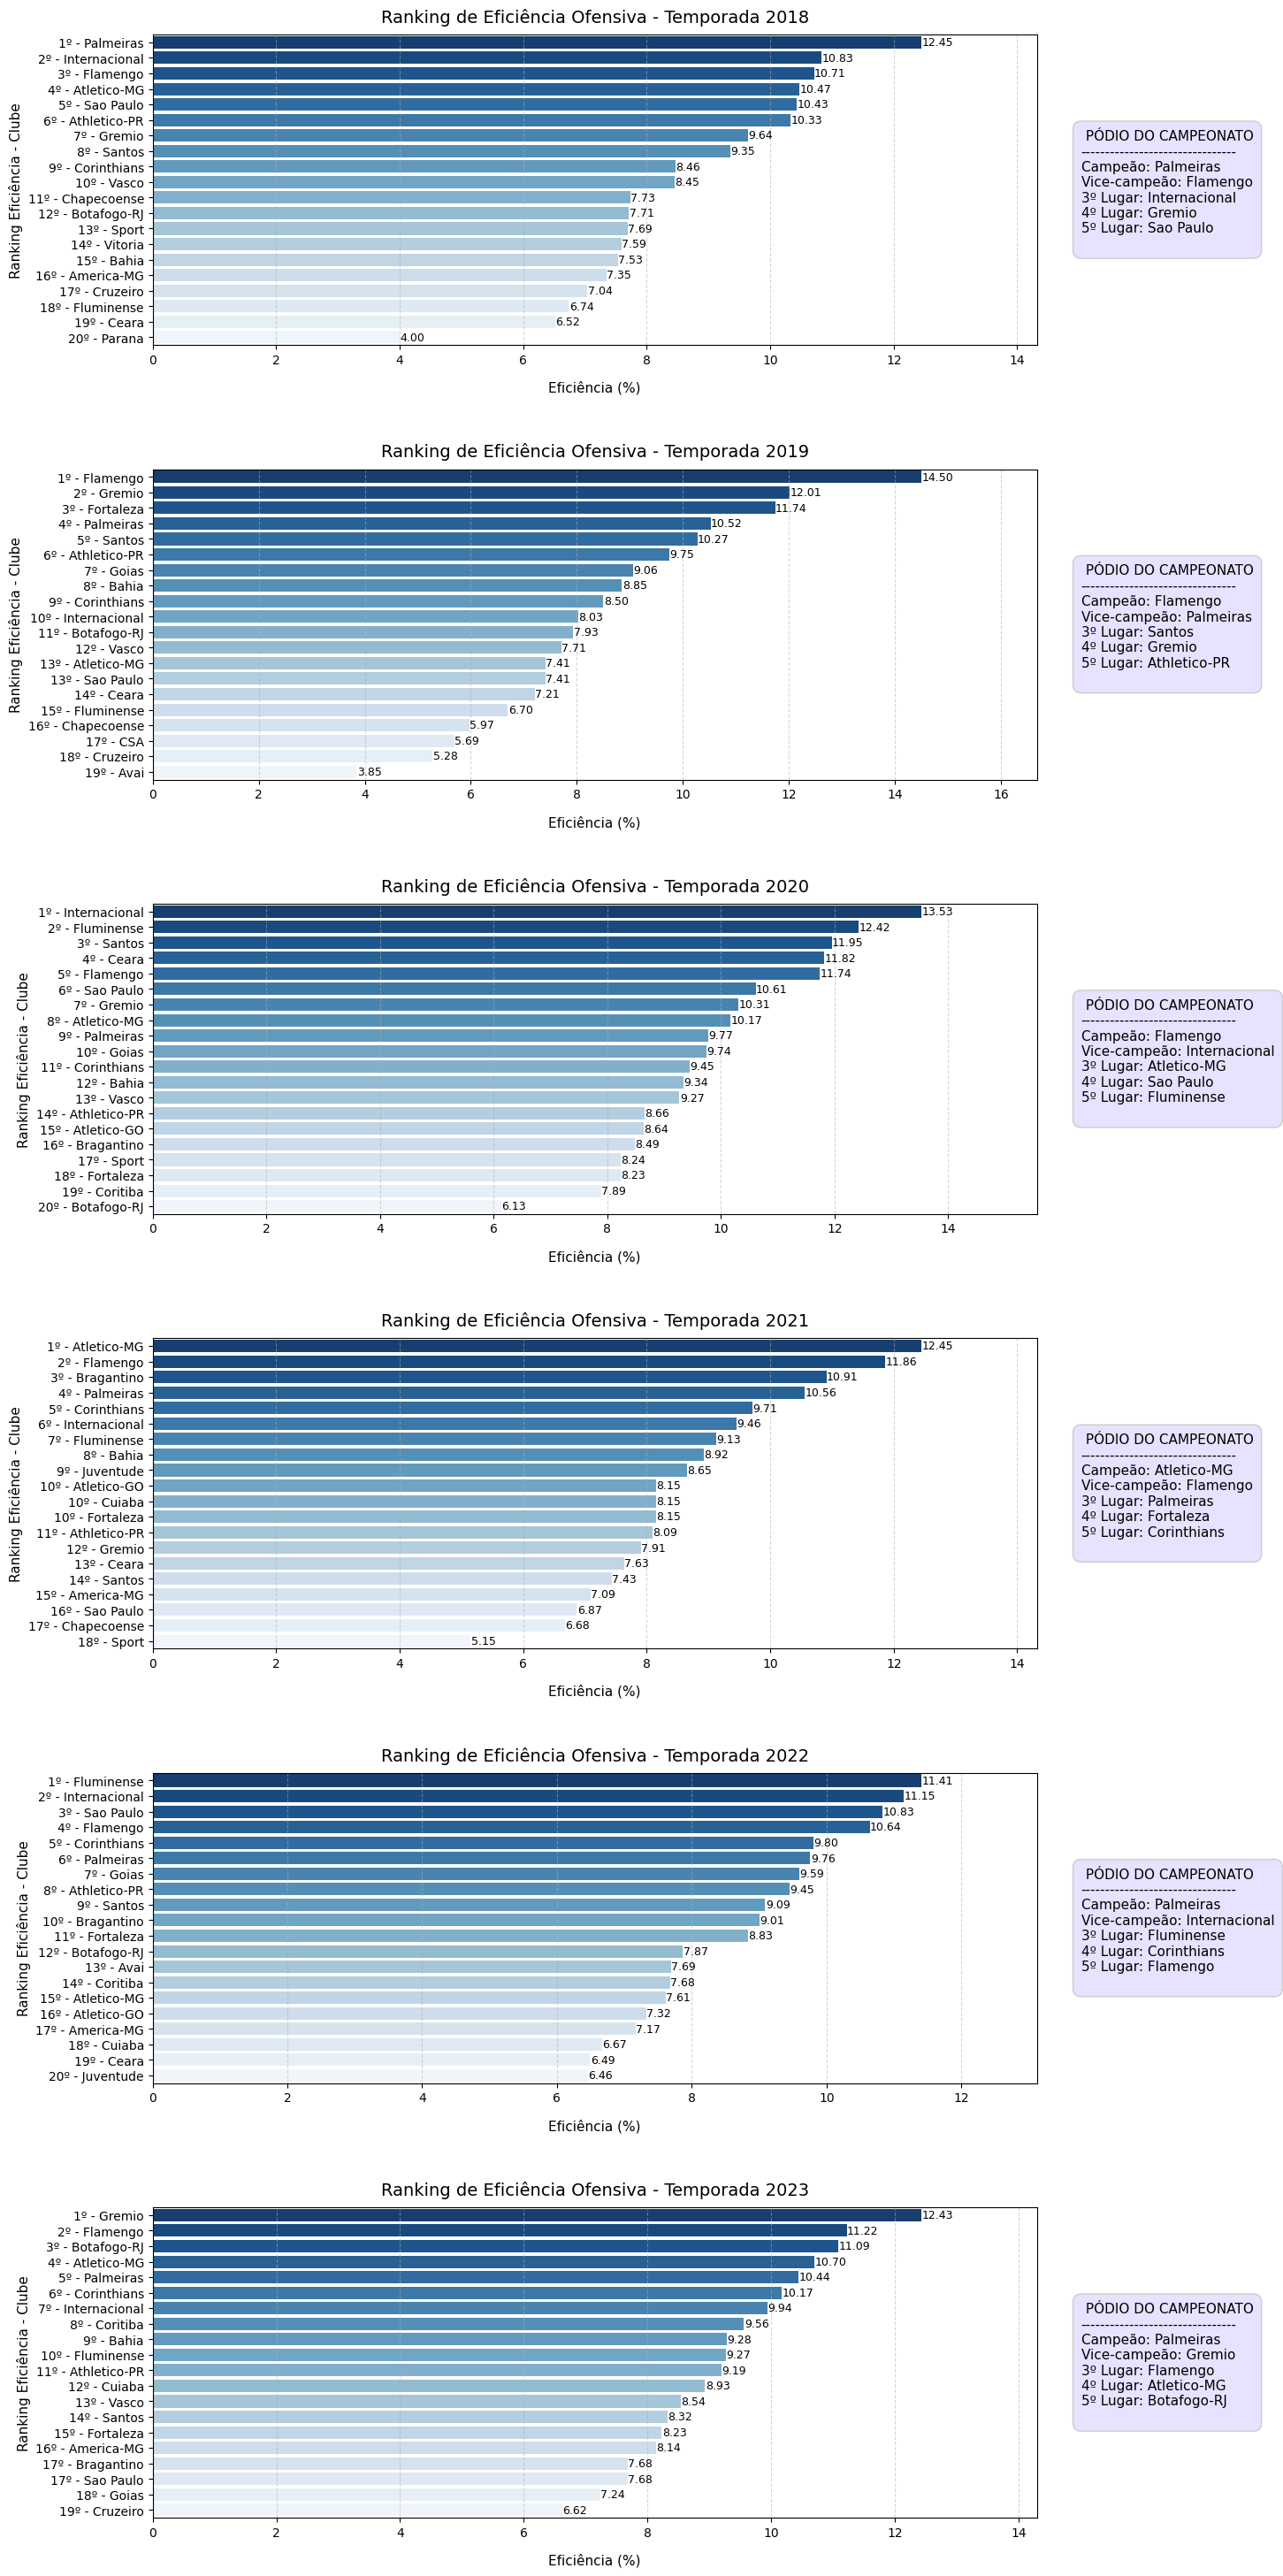

In [ ]:
#Identificar as temporadas únicas 
temporadas = eficiencia["ano"].unique()
num_temporadas = len(temporadas)

#Configurar a área do gráfico dinamicamente com base no número de anos
fig, axes = plt.subplots(
    nrows=num_temporadas,
    ncols=1,
    figsize=(16, 6 * num_temporadas),
    gridspec_kw={"right": 0.75},
)

# Garantir que 'axes' seja sempre uma lista, mesmo se houver apenas 1 temporada
if num_temporadas == 1:
    axes = [axes]

#Criar um gráfico de barras para cada temporada
for idx, ano in enumerate(temporadas):
    # Filtrar os dados de eficiência apenas do ano atual do loop
    dados_ano = eficiencia[eficiencia["ano"] == ano].copy()  # .copy() para evitar avisos do pandas

    # Criar a barra horizontal usando o Seaborn
    ax = axes[idx]
    sns.barplot(
        x="eficiencia_%",
        y="clube",
        data=dados_ano,
        palette="Blues_r",
        ax=ax,
        hue="clube",
        legend=False,
    )

    # Lista de textos combinando o Ranking + Nome do Clube
    novos_rotulos = [
        f"{row['ranking_ofensivo']}º - {row['clube']}" 
        for _, row in dados_ano.iterrows()
    ]
  
    ax.set_yticklabels(novos_rotulos)
   
    # Adicionar APENAS o valor da eficiência ao lado de cada barra
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            if width > 0:
                y_pos = bar.get_y() + bar.get_height() / 2
                texto = f"{width:.2f}"

                # Coloca o texto imediatamente após o fim da barra
                ax.text(
                    width + 0.005,
                    y_pos,
                    texto,
                    va="center",
                    ha="left",
                    fontsize=9,                )


    ax.margins(x=0.15)
    ax.tick_params(axis="x", labelbottom=True)

    # --- Buscar o Top 5 do campeonato no df_limpo de pontuação ---
    pontos_ano = colocacao[colocacao["ano"] == ano].head(5)

    time_campeao = pontos_ano.iloc[0]["clube"]
    time_vice = pontos_ano.iloc[1]["clube"]
    time_terceiro = pontos_ano.iloc[2]["clube"]
    time_quarto = pontos_ano.iloc[3]["clube"]
    time_quinto = pontos_ano.iloc[4]["clube"]

    # Monta a caixinha de texto formatada
    texto_podio = (
        f" PÓDIO DO CAMPEONATO\n"
        f"--------------------------------\n"
        f"Campeão: {time_campeao}\n"
        f"Vice-campeão: {time_vice}\n"
        f"3º Lugar: {time_terceiro}\n"
        f"4º Lugar: {time_quarto}\n"
        f"5º Lugar: {time_quinto}\n"
    )

    # Adiciona o texto fora do gráfico (à direita)
    ax.text(
        1.05,
        0.5,
        texto_podio,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="center",
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="#e6e2ff",
            edgecolor="#cccccc",
            alpha=1.0,
        ),
    )

    # Customizações estéticas por subgráfico
    ax.set_title(
        f"Ranking de Eficiência Ofensiva - Temporada {ano}", fontsize=14, pad=10
    )
    
   
    ax.set_xlabel("Eficiência (%)", fontsize=11, labelpad=12)
    ax.xaxis.get_label().set_visible(True)
    
    ax.set_ylabel("Ranking Eficiência - Clube", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Controla o espaçamento manualmente para que o nome do eixo X nunca seja cortado no fundo
plt.subplots_adjust(bottom=0.1, hspace=0.4)
plt.show()


Após analise visual dos gráficos decidimos relacionar os 5 primeiros colocados  e as 5 maiores eficiencias da temporada:

In [ ]:
# Unindo os dois rankings 
analise_completa = pd.merge(
    colocacao[["ano", "clube", "ranking_pontos", "pontos"]],
    eficiencia[["ano", "clube", "ranking_ofensivo", "eficiencia_%"]],
    on=["ano", "clube"]
)

# Filtrando apenas quem está no Top 5 de AMBOS os critérios ao mesmo tempo

times_em_ambos_top5 = analise_completa[
    (analise_completa["ranking_ofensivo"] <= 5) & 
    (analise_completa["ranking_pontos"] <= 5)
].sort_values(by=["ano", "ranking_pontos"])

# Quantos por cento do Top 5 ofensivo entrou no Top 5 de pontos?
taxa_sucesso = times_em_ambos_top5.groupby("ano")["clube"].count().reset_index()
taxa_sucesso = taxa_sucesso.rename(columns={"clube": "quantidade_de_times"})
taxa_sucesso["%_de_coincidencia"] = (taxa_sucesso["quantidade_de_times"] / 5) * 100




Apresentando gráfico relacionando 5 primeiros colocados da temporada com as 5 primeiras taxas de eficiencia ofensiva

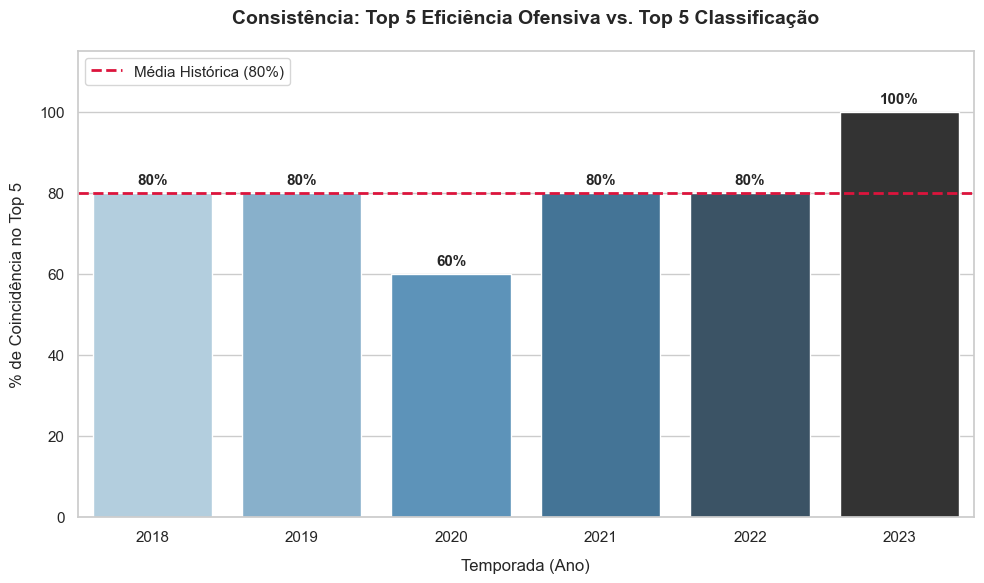

In [ ]:
# 1. Configurar o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico de barras baseado na sua tabela 'taxa_sucesso'
ax = sns.barplot(
    data=taxa_sucesso, 
    x="ano", 
    y="%_de_coincidencia", 
    palette="Blues_d",
    hue="ano",
    legend=False
)

# 3. Adicionar a linha da média histórica (80%)
media_historica = taxa_sucesso["%_de_coincidencia"].mean()
plt.axhline(
    y=media_historica, 
    color="crimson", 
    linestyle="--", 
    linewidth=2, 
    label=f"Média Histórica ({media_historica:.0f}%)"
)

# 4. Adicionar os rótulos de texto no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        f'{altura:.0f}%',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=11,
        weight='bold'
    )

# 5. Customizar títulos e eixos
plt.title("Consistência: Top 5 Eficiência Ofensiva vs. Top 5 Classificação", fontsize=14, pad=20, weight='bold')
plt.xlabel("Temporada (Ano)", fontsize=12, labelpad=10)
plt.ylabel("% de Coincidência no Top 5", fontsize=12, labelpad=10)
plt.ylim(0, 115) # Dá espaço para os rótulos de texto no topo
plt.legend(loc="upper left", fontsize=11)

# 6. Exibir o gráfico
plt.tight_layout()
plt.show()


Após análise podemos concluir que dentro da janela de dados avaliada há uma relação entre a eficiência ofensiva e o sucesso na tabela de classificação.
<br>
A média de coincidência ao longo desses 6 anos foi de 80% (24 de 30 possíveis), atingindo o ápice em 2023 com 100% de precisão.
<hr>

Analisando a correlação entre eficiência e pontos conquistados na partida
<h6>OBS.:O método .corr() do pandas usa correlação de Pearson por padrão, que pressupõe que ambas variaveis sejam contínuas, o que não ocorre com a variável "pontos".
<h6>Então escolhemos utilizar a correlação de Spearman que é mais indicada quando uma variável é ordinal



In [ ]:
correlacao = df_eficiencia["eficiencia_partida"].corr(df_eficiencia["pontos"], method="spearman")

print(
    f"A correlação entre Eficiência e Pontos na partida é de: {correlacao:.2f}"
)

KeyError: 'eficiencia_partida'

Uma correlação de 0,6 indica uma relação positiva moderada entre a Eficiência e os Pontos marcados na partida.
Isso indica que na maioria das vezes, a eficiência ofensiva se traduz em somar mais pontos na tabela (vitórias ou empates), mas sugere também que existam outros fatores que podem determinar o ganho de pontos.
<hr>

<center><h3>Analise da Formação Tática</h3></center>

A formação tática influencia a conquista de pontos das equipes? Existe uma formação com mais vitórias?

In [ ]:
df_formacao = df_limpo[['partida_id', 'clube', 'data', 'formacao_mandante','formacao_visitante', 'vencedor', 'mandante_Placar', 'visitante_Placar', 'ano','resultado', 'pontos',  'gols', 'eficiencia']].copy()
df_formacao

def get_formacao(row):
    if row['clube'] == row['mandante']:
        return row['formacao_mandante']
    else:
        return row['formacao_visitante']

df_formacao['formacao'] = df_limpo.apply(get_formacao, axis=1)
df_formacao = df_formacao[['partida_id', 'clube', 'data', 'ano', 'pontos',  'gols', 'eficiencia','formacao', 'resultado']]

display(df_formacao)

In [ ]:
vitorias = df_formacao[df_formacao['resultado'] =='Vitória'].rename(columns={'resultado': 'vitorias'})
vitorias = vitorias.groupby('formacao')['vitorias'].count().reset_index().sort_values(by='vitorias', ascending=False)

print('Formações mais vitoriosas:')
vitorias.head(3)

In [ ]:
print(f'Quantidade de formações distintas: {len(df_formacao['formacao'].unique())}')

In [ ]:


#Aprofundar no teste do qui quadrado
# 1. Cria a tabela de cruzamento (Frequência de resultados por formação)
tabela_cruzada = pd.crosstab(df_formacao['formacao'], df_formacao['resultado'])

# 2. Executa o Teste do Qui-Quadrado
chi2, p_valor, dof, expected = stats.chi2_contingency(tabela_cruzada)

print("--- RESULTADO DO TESTE ESTATÍSTICO ---")
print(f"P-Valor: {p_valor:.6f}")
if p_valor < 0.05:
    print("EXISTE correlação significativa. ")
else:
    print("NÃO existe correlação comprovada. Os resultados parecem independentes da formação utilizada.")


# 3. Criar um Ranking Prático das Formações por Média de Pontos
# Vamos filtrar formações raras (ex: que apareceram menos de 10 vezes) para não distorcer a análise
contagem_formacoes = df_formacao['formacao'].value_counts()
formacoes_validas = contagem_formacoes[contagem_formacoes >= 10].index

df_filtrado = df_formacao[df_formacao['formacao'].isin(formacoes_validas)]

ranking_formacao = df_filtrado.groupby('formacao')['pontos'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
ranking_formacao.columns = ['Total de Vezes Usada', 'Média de Pontos por Jogo']

print("--- RANKING DAS FORMAÇÕES MAIS VENCEDORAS (Mínimo 10 jogos) ---")
print(ranking_formacao.round(2))



## **Os campeões brasileiros apresentam um perfil estatístico diferente das demais equipes?**

Investigar se os campeões brasileiros apresentam um perfil estatístico diferente das demais equipes, comparando indicadores de desempenho ao longo das temporadas analisadas.

In [ ]:
# Carregamento da base de dados dos jogos do Campeonato Brasileiro (2018 a 2023).

df_limpo = pd.read_csv('campeonato_brasileiro_tratado.csv')
df_limpo.head()

### **Escolha das colunas relevantes para a análise.**

Colunas com informações dos indicadores de perfil de jogo (chutes, chutes no alvo, posse de bola, passes, precisão de passes, faltas, cartões amarelos e vermelhos, escanteios e pontos).

A coluna "pontos" não se caracteriza commo indicador de perfil de jogo, mas será utilizada para a análise de desempenho do time.

A coluna "ano" servirá para a divisão das analíses por temporada.

In [ ]:
indicadores = [
    'chutes',
    'chutes_no_alvo',
    'posse_de_bola',
    'passes',
    'precisao_passes',
    'faltas',
    'cartao_amarelo',
    'cartao_vermelho',
    'escanteios'
]

### **Verificação dos dados estatísticos**

Nesta etapa, verificamos os tipos de dados dos indicadores selecionados para confirmar se estão adequados aos cálculos estatísticos da análise.


In [ ]:
# verificação dos tipos de dados.

df_limpo[indicadores].dtypes

### **Estatísticas por equipe e temporada**

Como a base apresenta as estatísticas de cada partida, os dados serão agrupados por equipe e temporada, calculando-se a média de cada indicador selecionado.

In [ ]:
## Separamos os dados por ano e clube, trabalhando somente com as estatísticas presentes em 'indicadores'.

media_estatisticas = (
    df_limpo.groupby(['ano', 'clube'])[indicadores]   # Separamos os dados por ano e clube, trabalhando somente com as estatísticas presente em indicadores
    .mean()                                     # Calculamos a média de cada estatística para cada clube em cada ano
    .round(2)                                   # Arredondamos os valores para duas casas decimais (para melhor visualização)
    .reset_index()                              # Resetamos o índice do DataFrame resultante
)

media_estatisticas.head(20)

### **Classificação final por temporada**

A classificação final de cada temporada será obtida a partir da pontuação acumulada pelas equipes, permitindo identificar o campeão de cada edição analisada.

A coluna 'pontos' representa os pontos conquistados em cada partida, onde cada vitória equivale a 3 pontos, empate 1 ponto e derrota 0 ponto

In [ ]:
# agrupa os registros por ano e clube e soma todos os pontos conquistados.

classificacao = (
    df_limpo.groupby(['ano', 'clube'])['pontos']
    .sum()
    .reset_index()
)

# organização da tabela pelo ano e pela pontuação.

classificacao = classificacao.sort_values(
    ['ano', 'pontos'],
    ascending=[True, False]
)

# cria uma nova coluna chamada posicao.

classificacao['posicao'] = (
    classificacao.groupby('ano')['pontos']
    .rank(method='first', ascending=False)
    .astype(int)
)

# Sem cálculos de média, apenas identificando a colocação final de cada time por ano e quantidade de pontos.

classificacao = classificacao[
    ['ano', 'posicao', 'clube', 'pontos']
]

classificacao.head(20)
# Descobrir os campeões da cada ano, ou seja, os clubes que ficaram na primeira posição.

campeoes = classificacao.loc[
    classificacao.groupby("ano")["pontos"].idxmax()
]

campeoes

### **Integração das estatísticas com a classificação**

As médias estatísticas de cada equipe serão relacionadas à sua respectiva classificação final em cada temporada, permitindo comparar o perfil dos campeões com o das demais equipes.

In [ ]:
# Criamos um novo DataFrame chamado 'dados_analise'. Efetuamos o merge dos dois df_limpo's existentes (classificacao e media_estatisticas) com base nas colunas 'ano' e 'clube', que são comuns a ambos.

dados_analise = pd.merge(
    classificacao,
    media_estatisticas,
    on=['ano', 'clube']
)

# Criaçãod e uma nova coluna chamada 'classificacao final' que classifica os clubes como 'CAMPEÃO' se estiverem na primeira posição, 'REBAIXADO' se estiverem nas posições 17 a 20, e vazio para os demais.
# Serve para observarmos se até um time rebaixado pode superar o campeão em determinado indicador. O futebol não é uma ciência exata!

dados_analise['classificacao final'] = dados_analise['posicao'].apply(lambda x: 'CAMPEÃO' if x == 1 else 'REBAIXADO' if x in [17, 18, 19, 20] else '')

dados_analise.head(20)

### **Comparação entre campeões e demais equipes**

Comparar o perfil estatístico médio dos campeões com o de todas as demais equipes, independentemente da posição final.

In [ ]:
# criação dos Dadaframes 'campeoes' e demais para separar os clubes campeões dos demais clubes.

campeoes = dados_analise[
    dados_analise['posicao'] == 1
]

demais = dados_analise[
    dados_analise['posicao'] != 1
]
# Média das estatísticas dos campeões e dos demais clubes.

media_campeoes = campeoes[indicadores].mean().round(2)
media_demais = demais[indicadores].mean().round(2)

# Comparação entre os dataframes de médias dos campeões e dos demais clubes

comparacao = pd.DataFrame({
    'Campeões': media_campeoes,
    'Demais equipes': media_demais
})

# inclusão da coluna diferença percentual entre os campeões e os outros clubes.

comparacao['Diferença (%)'] = (
    (comparacao['Campeões'] - comparacao['Demais equipes'])
    / comparacao['Demais equipes'] * 100
).round(2)

comparacao

### **Comparação por temporada**

Até agora, a gente olhou para todas as temporadas juntas e tirou uma média geral. Mas agora queremos dar um passo diferente: Em cada temporada, como o campeão se saiu em relação às outras equipes daquele ano?

Dessa forma, evitamos que essa média geral esconda diferenças importantes de cada temporada. Exemplo: o Palmeiras de 2018 não tem as mesmas estatísticas do Palmeiras de 2023

In [ ]:
# Média das equipes (exceto o campeão) por ano, para cada indicador.

media_demais_ano = (
    demais.groupby('ano')[indicadores]
    .mean()
    .round(2)
    .reset_index()
)

media_demais_ano

# Dados dos campeões por ano, para cada indicador.

campeoes_ano = campeoes[
    ['ano', 'clube'] + indicadores
].copy()

campeoes_ano

# utilizei o comando 'suffixes' para diferenciar as colunas com as estatísticas do campeão de cada ano e os demais clubes.

comparacao_ano = pd.merge(
    campeoes_ano,
    media_demais_ano,
    on='ano',
    suffixes=('_campeao', '_demais')
)
comparacao_ano


### **Diferença por temporada**

Já temos o Dataframe de comparação, agora queremos calcular, para cada indicador, quanto o campeão ficou acima ou abaixo da média das demais equipes naquele ano.

In [ ]:
# Cada item do for a seguir representa a diferença (percentual) do campeão em relação às demais (por temporada)

for indicador in indicadores:
    comparacao_ano[f'{indicador}_dif'] = (
        (comparacao_ano[f'{indicador}_campeao'] -
         comparacao_ano[f'{indicador}_demais'])
        / comparacao_ano[f'{indicador}_demais'] * 100
    ).round(2)
colunas_diferenca = [
    'ano',
    'clube'
] + [f'{indicador}_dif' for indicador in indicadores]

comparacao_ano[colunas_diferenca]

### **Visualização dos resultados**

Quanto os campeões diferem das demais equipes em cada indicador?

In [ ]:
import plotly.graph_objects as go
indicadores_grafico = comparacao.index.tolist()
diferenca_geral = comparacao['Diferença (%)'].tolist()
botoes = [
    dict(
        label='GERAL',
        method='update',
        args=[
            {
                'x': [diferenca_geral],
                'y': [indicadores_grafico],
                'text': [diferenca_geral]
            },
            {
                'title': 'Diferença percentual entre campeões e demais equipes'
            }
        ]
    )
]
for _, linha in comparacao_ano.iterrows():

    ano = linha['ano']
    clube = linha['clube']

    diferencas = [
        linha[f'{indicador}_dif']
        for indicador in indicadores
    ]

    botoes.append(
        dict(
            label=str(ano),
            method='update',
            args=[
                {
                    'x': [diferencas],
                    'y': [indicadores],
                    'text': [diferencas]
                },
                {
                    'title': f'{clube} ({ano}) × demais equipes'
                }
            ]
        )
    )
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=diferenca_geral,
        y=indicadores_grafico,
        orientation='h',
        text=diferenca_geral,
        texttemplate='%{text:.2f}%',
        customdata=comparacao[['Campeões', 'Demais equipes']],
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Campeões: %{customdata[0]:.2f}<br>'
            'Demais equipes: %{customdata[1]:.2f}<br>'
            'Diferença: %{x:.2f}%'
            '<extra></extra>'
        )
    )
)
fig.update_layout(
    updatemenus=[
        dict(
            buttons=botoes,
            direction='down',
            showactive=True,
            x=1,
            y=1.15
        )
    ],
    xaxis_title='Diferença (%)',
    yaxis_title='Indicador',
    title='Diferença percentual entre campeões e demais equipes'
)

fig.show()

In [ ]:
comparacao_ano[colunas_diferenca]

## **Qual time consegue produzir mais gols a cada 100 passes realizados?**

Investigar quais equipes apresentam maior eficiência na produção de gols em relação ao volume de passes realizados, utilizando como indicador a quantidade de gols marcados a cada 100 passes. A análise considera as temporadas disponíveis na base, permitindo comparar o desempenho das equipes tanto de forma geral quanto por temporada.

### **Escolha das colunas relevantes para a análise.**

Colunas com informações dos indicadores de perfil de jogo (passes, mandante_Placar e visitante_Placar).

As colunas "clube", "mandante", "visitante" e "pontos" não se caracterizam commo indicadores de perfil de jogo, mas serão utilizadas para a análise de desempenho dos times.

A coluna "ano" servirá para a divisão das analíses por temporada.

In [ ]:
indicadores_2 = [
    'ano',
    'clube',
    'mandante',
    'visitante',
    'mandante_Placar',
    'visitante_Placar',
    'passes'
]
df_limpo_gols = df_limpo[indicadores_2].copy()

### **Construir a quantidade de gols marcados**

Como os placares estão separados entre mandante e visitante, precisamos determinar quantos gols pertencem ao clube representado em cada linha.

In [ ]:
# A fim de facilitar as nossas análises e cálculos, faremos a criação da coluna 'gols_marcados' para armazenar os gols dos mandantes assim como dos visitantes.

df_limpo_gols['gols_marcados'] = np.where(
    df_limpo_gols['clube'] == df_limpo_gols['mandante'],
    df_limpo_gols['mandante_Placar'],
    df_limpo_gols['visitante_Placar']
)

df_limpo_gols.head(10)
df_limpo_gols.columns

### **Agrupar os dados por clube e temporada**

Efetuar o agrupamento dos dados das colunas selecionadas e separá-los por clube/temporada

In [ ]:
# Gols por clube e temporada

gols_por_temporada = (
    df_limpo_gols.groupby(['ano', 'clube'])['gols_marcados']
    .sum()
    .reset_index()
)
# ordenando por campeonato

gols_por_temporada = gols_por_temporada.sort_values(
    ['ano', 'gols_marcados'],
    ascending=[True, False]
)

gols_por_temporada

# Somatório geral por time

gols_geral = (
    df_limpo_gols.groupby('clube')['gols_marcados']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

gols_geral

### **Calcular a eficiência**

Através da criação da coluna 'gols_por_100_passes', nos permitirá comparar clubes que tiveram volumes diferentes de passes.

In [ ]:
# Agrupamos os dados por ano e clube e somamos todos os gols e também os passes de um determinado clube por emporada.

eficiencia = (
    df_limpo_gols.groupby(['ano', 'clube'])[
        ['gols_marcados', 'passes']
    ]
    .sum()
    .reset_index()
)
# Dividimos o total de gols pelo total de passes e multiplicamos o resultado por 100, obtendo a quantidade de gols marcados a cada 100 passes realizados.

eficiencia['gols_por_100_passes'] = (
    eficiencia['gols_marcados']
    / eficiencia['passes']
    * 100
).round(3)

#Ordenados pela eficiência (do maior para o menor) Portanto, o primeiro colocado será o time mais eficiente entre 2018 e 2023.

eficiencia = eficiencia.sort_values(
    'gols_por_100_passes',
    ascending=False
)

eficiencia

### **Criar o ranking geral**

Ordenar os clubes pela eficiência para descobrir quais times-temporada apresentaram os maiores valores entre 2018 e 2023.

In [ ]:
# criando a coluna 'ranking' no Dataframe 'eificencia' usando a eficiência de cada time.

eficiencia['ranking'] = (
    eficiencia['gols_por_100_passes']
    .rank(method='min', ascending=False)
    .astype(int)
)
# Selecionando as colunas necessárias para visualizar o ranking geral de eficiência entre 2018 e 2023.

ranking_eficiencia = eficiencia[
    [
        'ranking',
        'ano',
        'clube',
        'gols_marcados',
        'passes',
        'gols_por_100_passes'
    ]
].sort_values('ranking')

ranking_eficiencia

### **Analisar por temporada**

Separar o resultado por ano para evitar que o ranking geral esconda diferenças entre temporadas.

In [ ]:
# primeiro separamos os clubes por ano e dentro de cada ano criamos o ranking usando 'gols_por_100_passes'. O maior valor recebe posição 1.

eficiencia['ranking_temporada'] = (
    eficiencia.groupby('ano')['gols_por_100_passes']
    .rank(method='min', ascending=False)
    .astype(int)
)
# Selecionamos apenas as colunas importantes e organizamos primeiro pelo ano e depois pela posição no ranking.

ranking_temporada = eficiencia[
    [
        'ano',
        'ranking_temporada',
        'clube',
        'gols_marcados',
        'passes',
        'gols_por_100_passes'
    ]
].sort_values(
    ['ano', 'ranking_temporada']
)

ranking_temporada

# Por ano (exemplo 2018)

ranking_temporada[
    ranking_temporada['ano'] == 2018

]

### **Relacionar eficiência e desempenho**

Ser eficiente em gols por passes está associado a terminar melhor no campeonato?

In [ ]:
# Aqui iremos encontrar o mesmo ano e clube nos DataFrames e reunir as informações em 'eficiencia_desempenho'. Esse será o DataFrame final com todas as informações que precisamos para a análise.

eficiencia_desempenho = pd.merge(
    eficiencia,
    dados_analise[['ano', 'clube', 'posicao', 'pontos']],
    on=['ano', 'clube']
)
# Criamos um ranking de eficiência ofensiva para cada temporada, considerando a quantidade de gols marcados a cada 100 passes..
# Detalhe: só comparamos tal eficiência entre os clubes que disputaram a mesma temproada.

eficiencia_desempenho['ranking_eficiencia'] = (
    eficiencia_desempenho
    .groupby('ano')['gols_por_100_passes']
    .rank(method='min', ascending=False)
    .astype(int)
)
# Somente os campeões e mostra sua posição do ranking de eficiencia

campeoes_letalidade = (
    eficiencia_desempenho[
        eficiencia_desempenho['posicao'] == 1
    ][
        [
            'ano',
            'clube',
            'pontos',
            'gols_marcados',
            'gols_por_100_passes',
            'ranking_eficiencia'
        ]
    ]
    .sort_values('ano')
)

campeoes_letalidade

### **Construir a visualização**

In [ ]:
fig = go.Figure()

anos = sorted(eficiencia_desempenho['ano'].unique())

for ano in anos:

    dados_ano = (
        eficiencia_desempenho[
            eficiencia_desempenho['ano'] == ano
        ]
        .sort_values('gols_por_100_passes')
    )

    nomes_clubes = [
        f"<b>🏆 {clube}</b>" if posicao == 1 else clube
        for clube, posicao in zip(
            dados_ano['clube'],
            dados_ano['posicao']
        )
    ]

    fig.add_trace(
        go.Bar(
            x=dados_ano['gols_por_100_passes'],
            y=nomes_clubes,
            orientation='h',
            text=dados_ano['gols_por_100_passes'],
            texttemplate='%{text:.3f}',
            customdata=dados_ano[
                ['posicao', 'gols_marcados', 'passes']
            ],
            hovertemplate=(
                '<b>%{y}</b><br>'
                'Eficiência: %{x:.3f} gols/100 passes<br>'
                'Gols: %{customdata[1]}<br>'
                'Passes: %{customdata[2]}<br>'
                'Posição no campeonato: %{customdata[0]}º'
                '<extra></extra>'
            ),
            name=str(ano),
            visible=(ano == anos[0])
        )
    )

botoes = []

for i, ano in enumerate(anos):

    visibilidade = [False] * len(anos)
    visibilidade[i] = True

    botoes.append(
        dict(
            label=str(ano),
            method='update',
            args=[
                {'visible': visibilidade},
                {'title': f'Eficiência ofensiva por passes — {ano}'}
            ]
        )
    )

fig.update_layout(
    title=f'Eficiência ofensiva por passes — {anos[0]}',
    xaxis_title='Gols a cada 100 passes',
    yaxis_title='Clube',
    updatemenus=[
        dict(
            buttons=botoes,
            direction='down',
            showactive=True,
            x=1,
            y=1.12
        )
    ],
    height=650
)

fig.show()



<span style="color: red; font-size: 18px"> OBS.: Aguardar limpeza dos dados para fazer a relação entre eficiencia e melhor colocação, se houver</span>
<br>
<br>
<br>
<br>